En el siguiente proyecto utilizo un dataset que contiene transacciones de un comercio de retail descargado desde Kaggle con el objetivo de analizar el comportamiento de los clientes encontrando habitos de consumo y entendiendo que tan saludable es la retencion del negocio

Preguntas guia para lograr el objetivo del proyecto:
1. Los clientes que pagan con tarjeta de crédito, ¿gastan montos más altos y variables que los que pagan en efectivo?
2. ¿Cual es el revenue por categoria?. ¿y el gasto tipico de los clientes por categoria?
3. ¿Cual es la participacion de los clientes en el revenue?
4. ¿Cuál es el nivel de retención de nuestros clientes?
5. ¿En qué horario existe la mayor cantidad de transacciones?

In [1]:
import pandas as pd
import psycopg2
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
from dotenv import load_dotenv
import os

Cargo el .csv con pandas y realizo una exploracion del dataframe para saber si los datos son validos, sus formatos son correctos, que tipo de datos son, si estan completos.

In [2]:
url = 'https://raw.githubusercontent.com/MartinArielAlvarado/data-portfolio/refs/heads/main/data/raw/Retail_Transaction_Dataset.csv'
df_transactions = pd.read_csv(url)

In [3]:
df_transactions.info()
#--------------------------------------------------------------
df_transactions.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   CustomerID          100000 non-null  int64  
 1   ProductID           100000 non-null  str    
 2   Quantity            100000 non-null  int64  
 3   Price               100000 non-null  float64
 4   TransactionDate     100000 non-null  str    
 5   PaymentMethod       100000 non-null  str    
 6   StoreLocation       100000 non-null  str    
 7   ProductCategory     100000 non-null  str    
 8   DiscountApplied(%)  100000 non-null  float64
 9   TotalAmount         100000 non-null  float64
dtypes: float64(3), int64(2), str(5)
memory usage: 7.6 MB


CustomerID            0
ProductID             0
Quantity              0
Price                 0
TransactionDate       0
PaymentMethod         0
StoreLocation         0
ProductCategory       0
DiscountApplied(%)    0
TotalAmount           0
dtype: int64

In [4]:
df_transactions.head()

,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2023 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,8/5/2023 0:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,3/11/2024 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2023 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2023 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [5]:
df_transactions.describe()

,CustomerID,Quantity,Price,DiscountApplied(%),TotalAmount
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,500463.982180,5.009290,55.067344,10.020155,248.334955
std,288460.917524,2.579808,25.971567,5.779534,184.554792
min,14.000000,1.000000,10.000430,0.000046,8.274825
25%,250693.750000,3.000000,32.549474,5.001013,95.163418
50%,499679.000000,5.000000,55.116789,10.030353,200.368393
75%,751104.750000,7.000000,77.456763,15.018367,362.009980
max,999997.000000,9.000000,99.999284,19.999585,896.141242


Notar que resulta util cambiar el tipo de dato de 'TransactionDate' de manera tal que me permita realizar operaciones para el analisis temporal. Ademas, agregar una columna 'Hour' me permite analizar una posible relacion entre horario y transacciones.

In [6]:
df_transactions['TransactionDate'] = pd.to_datetime(df_transactions['TransactionDate'])

In [7]:
df_transactions['Hour'] = df_transactions['TransactionDate'].dt.hour

Despues de la transformacion cargo el dataframe a la base de datos en PostgreSQL para estar habilitado a consultas simultaneas y no dependa de mi PC

La instancia de carga del dataframe a la base de datos es local, use archivos de variables de entorno para mantener las credenciales ocultas. Para continuar con las consultar por SQL uso el gestor DBeaver y capturas de pantalla para cada consulta.

In [8]:
load_dotenv()

connection = os.getenv('DATABASE_URL')
motor = create_engine(connection)

df_transactions.to_sql('Transacciones', con=motor, if_exists='replace', index=False)

1000

Pasemos a las preguntas que incentivan el analisis:

1.Los clientes que pagan con tarjeta de crédito, ¿gastan montos más altos y variables que los que pagan en efectivo?

Hagamos una comparacion entre metodos de pago. Luego, analicemos y comparemos el ticket promedio y la mediana del ticket por metodo de pago.

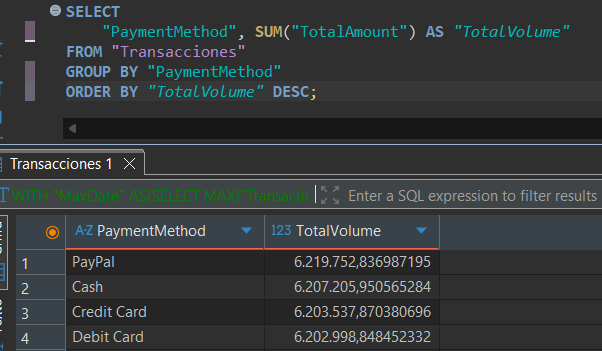

Planteo el uso de una query para SQL pero no la ejecuto por ser de entorno local. A continuacion, ejecuto la misma instruccion pero con Pandas para graficar con Seaborn Objects

In [62]:
#query="""
#    SELECT
#	  "PaymentMethod", SUM("TotalAmount") AS "TotalVolume"
#    FROM "Transacciones"
#    GROUP BY "PaymentMethod"
#    ORDER BY "TotalVolume" DESC;
#"""
#df_paymentmethod = pd.read_sql(query, con=motor)

df_paymentmethod = df_transactions.groupby('PaymentMethod')['TotalAmount'].sum().reset_index()
df_paymentmethod.columns = ['PaymentMethod', 'TotalVolume']
df_paymentmethod['TotalVolume']=round(df_paymentmethod['TotalVolume'],2)
display(df_paymentmethod.sort_values(by='TotalVolume',ascending=False))

,PaymentMethod,TotalVolume
3,PayPal,6219752.84
0,Cash,6207205.95
1,Credit Card,6203537.87
2,Debit Card,6202998.85


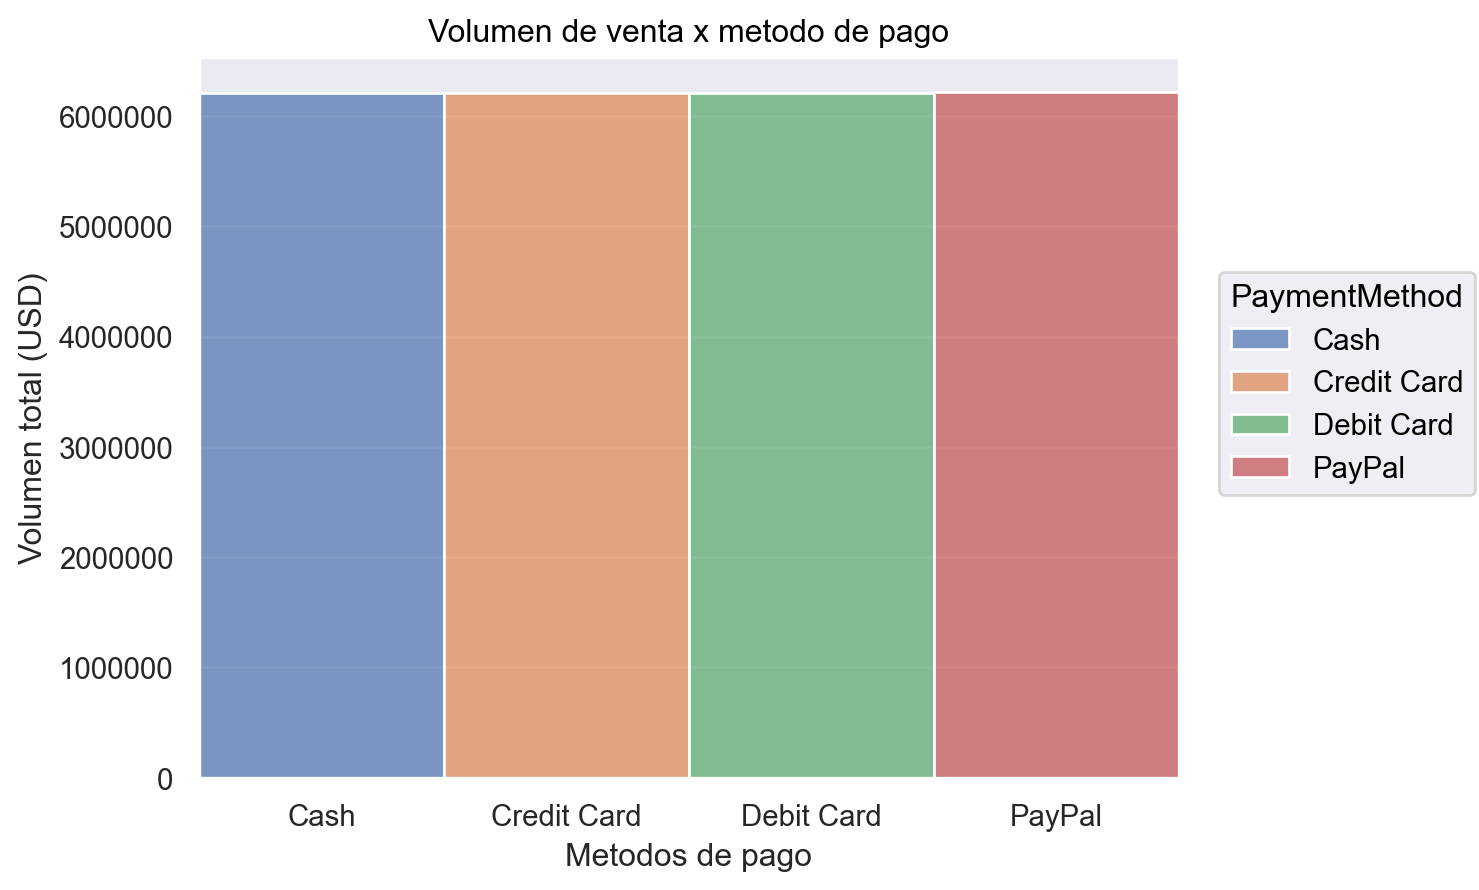

In [54]:
(
    so.Plot(data=df_paymentmethod, x='PaymentMethod', y='TotalVolume', color='PaymentMethod')
    .add(so.Bars())
    .label(x='Metodos de pago', y='Volumen total (USD)', title='Volumen de venta x metodo de pago')
    .scale(y=so.Continuous().label(like="{x:.0f}"))
)

La diferencia entre los metodos de pagos es poca...
Podria estar ocultando informacion sobre el comportamiento de los clientes. Veamos el ticket promedio y la mediana del ticketpor metodo de pago

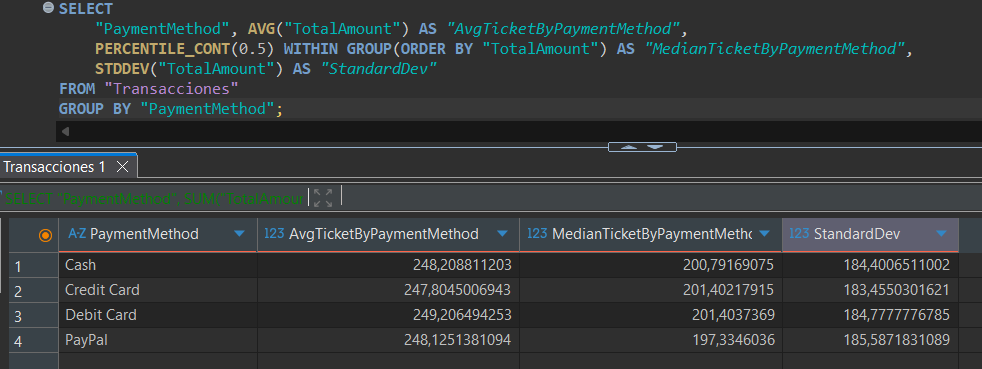

In [61]:
#query ="""
#    SELECT
#	  "PaymentMethod", AVG("TotalAmount") AS "AvgTicketByPaymentMethod",
#	  PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY "TotalAmount") AS "MedianTicketByPaymentMethod",
#	  STDDEV("TotalAmount") AS "StandardDev"
#   FROM "Transacciones"
#   GROUP BY "PaymentMethod";
#"""

#df_media_mediana = pd.read_sql(query, con=motor)

df_media_mediana = df_transactions.groupby('PaymentMethod').agg({'TotalAmount':['mean','median','std']}).reset_index()
df_media_mediana.columns = ['PaymentMethod', 'Mean', 'Median', 'STDdev']
display(df_media_mediana)

,PaymentMethod,Mean,Median,STDdev
0,Cash,248.208811,200.791691,184.400651
1,Credit Card,247.804501,201.402179,183.455030
2,Debit Card,249.206494,201.403737,184.777778
3,PayPal,248.125138,197.334604,185.587183


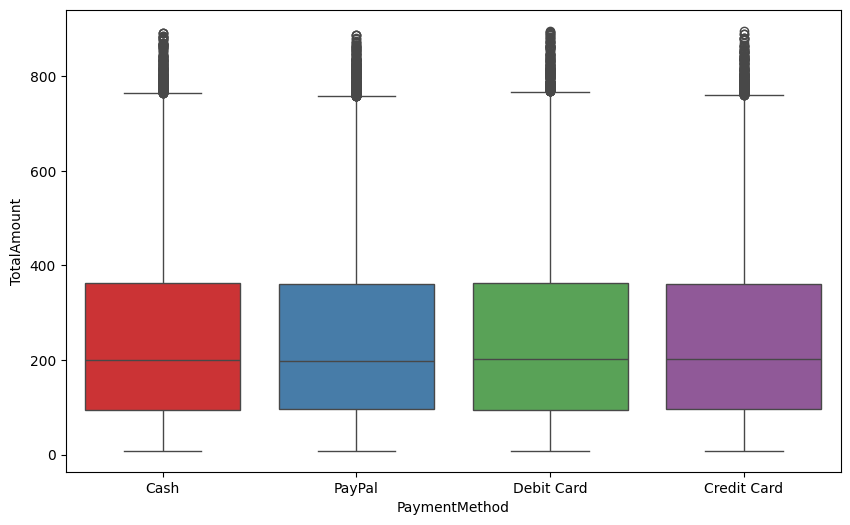

In [70]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_transactions, x='PaymentMethod', y='TotalAmount', hue='PaymentMethod', palette='Set1', legend=False, ax=ax)
plt.show()

Los datos de la tabla entre media de ticket, mediana de ticket y desvio estandar nos dice que el promedio esta sesgado hacia la derecha. Con el grafico de boxplot podemos ver ese sesgo con los valores atipicos que corren ese promedio hacia valores mas altos. Respondiendo a la pregunta: no, los clientes que compran con tarjeta de credito tienen valores de ticket similares a los que compran con efectivo.

2.¿Cual es el revenue por categoria?. ¿y el gasto tipico de los clientes por categoria?

Veamos los montos totales de ventas, media y mediana de los tickets por categoria.

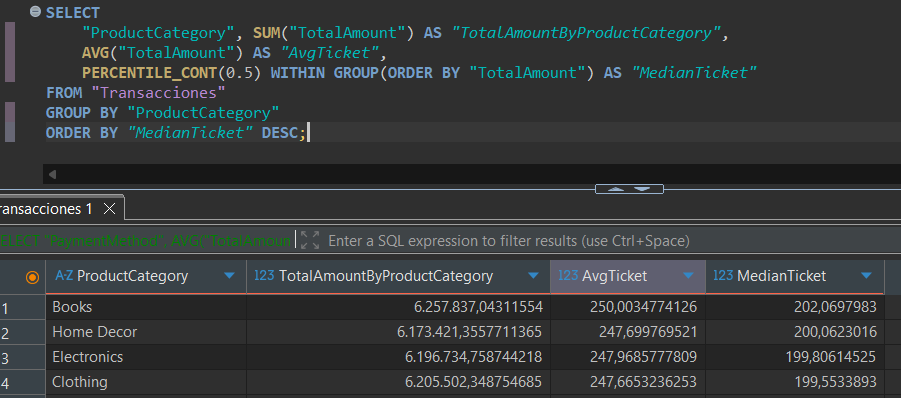

In [89]:
#query = """
#    SELECT
#    	"ProductCategory", SUM("TotalAmount") AS "TotalAmountByProductCategory",
#    	AVG("TotalAmount") AS "AvgTicket",
#    	PERCENTILE_CONT(0.5) WITHIN GROUP(ORDER BY "TotalAmount") AS "MedianTicket"
#    FROM "Transacciones"
#    GROUP BY "ProductCategory"
#    ORDER BY "MedianTicket" DESC;
#"""
#df_categ = pd.read_sql(query, con=motor)

df_categ = df_transactions.groupby('ProductCategory').agg({'TotalAmount':['sum','mean','median']}).reset_index()
df_categ.columns = ['ProductCategory','Revenue', 'Mean', 'Median']
df_categ['Revenue']=round(df_categ['Revenue'],2)
display(df_categ.sort_values(by='Revenue', ascending=False))

,ProductCategory,Revenue,Mean,Median
0,Books,6257837.04,250.003477,202.069798
1,Clothing,6205502.35,247.665324,199.553389
2,Electronics,6196734.76,247.968578,199.806145
3,Home Decor,6173421.36,247.699770,200.062302


El revenue por categoria resulta parejo (analogo a los metodos de pago) y la media y mediana nos muestran sesgo hacia la derecha tambien. Seria de utilidad conocer los margenes por categoria para profundizar en el analisis.

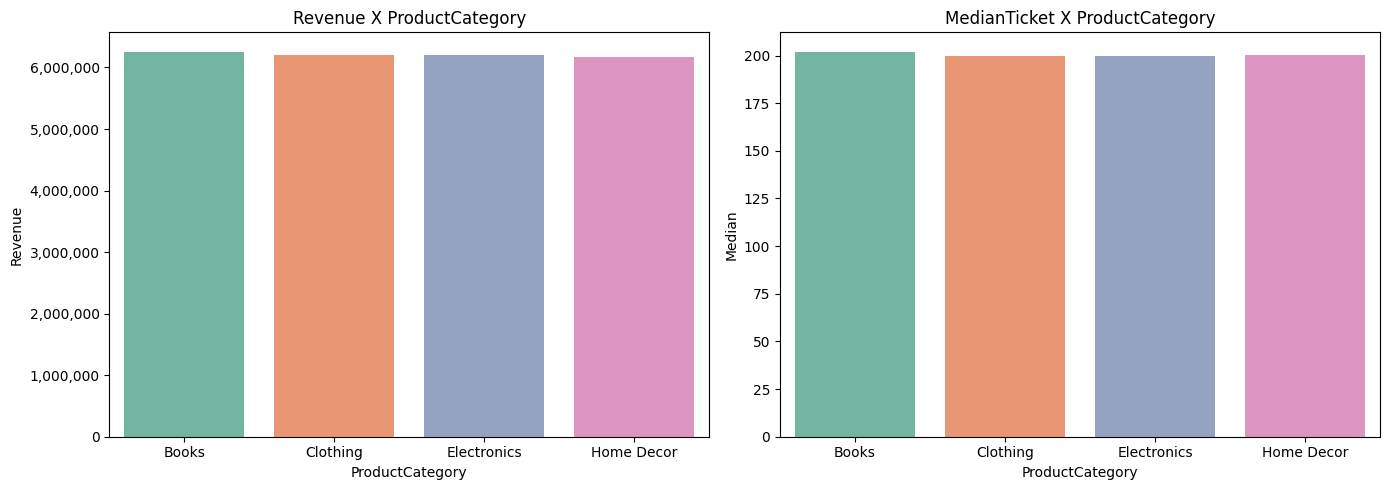

In [103]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_categ, x='ProductCategory', y='Revenue', hue='ProductCategory', palette='Set2', legend=False, ax=ax1)
sns.barplot(data=df_categ, x='ProductCategory', y='Median', hue='ProductCategory', palette='Set2', legend=False, ax=ax2)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.set_title('Revenue X ProductCategory')
ax2.set_title('MedianTicket X ProductCategory')
plt.tight_layout()
plt.show()

3.¿Cual es la participacion de los clientes en el revenue?

Planteamos el porcentaje del revenue que representa cada cliente y luego la suma acumulada de esos porcentajes. Los clientes deben estar ordenados de manera decreciente por su revenue.

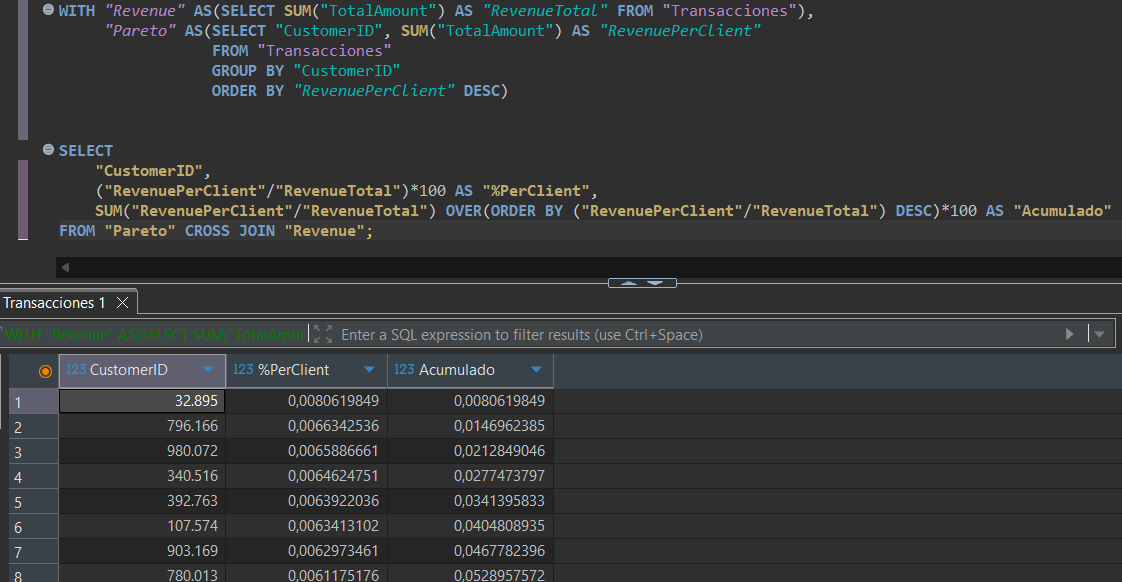

Mejoremos esta consulta para contar los clientes que acumulan el 80% del revenue.

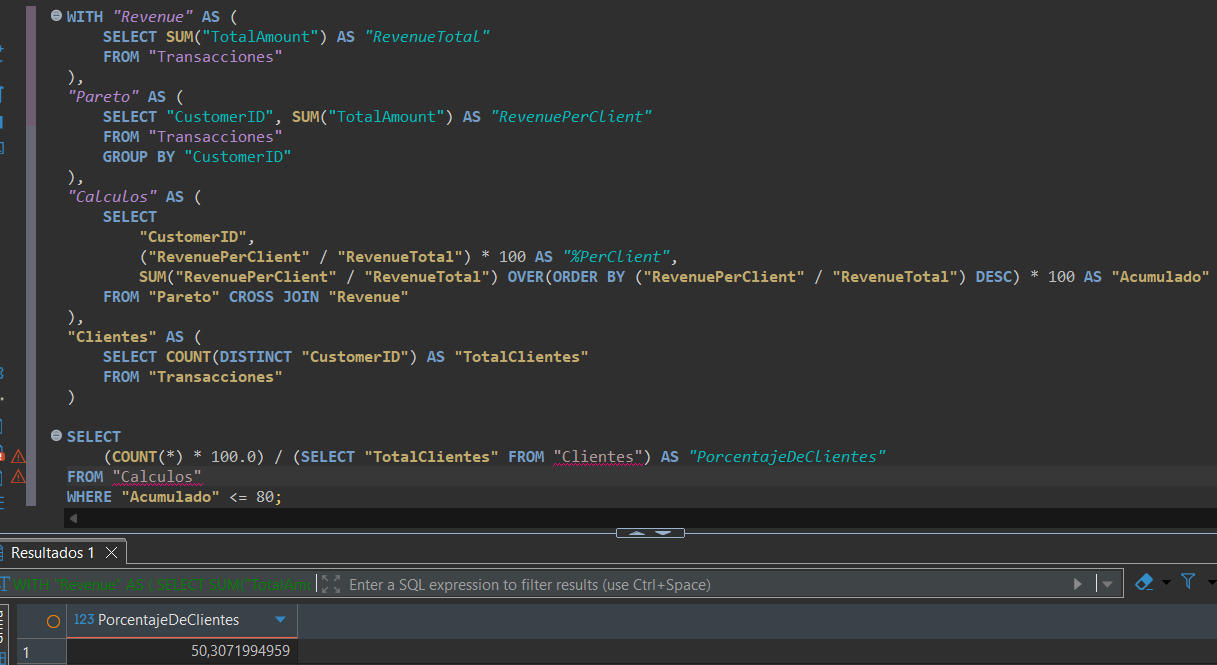

Hagamos lo mismo en pandas y luego grafiquemos para verificar este resultado.

In [140]:
df_pareto = df_transactions.groupby('CustomerID')['TotalAmount'].sum().reset_index()
df_pareto['%perCustomer'] = df_pareto['TotalAmount']/df_pareto['TotalAmount'].sum()
df_pareto = df_pareto.sort_values(by='TotalAmount', ascending=False)
df_pareto['AccSum'] = df_pareto['%perCustomer'].cumsum() * 100
df_pareto = df_pareto.reset_index(drop=True)
df_pareto['%customer'] = ((df_pareto.index +1)/len(df_pareto))*100
display(df_pareto)

,CustomerID,TotalAmount,%perCustomer,AccSum,%customer
0,32895,2002.072661,8.061985e-05,0.008062,0.001050
1,796166,1647.517063,6.634254e-05,0.014696,0.002101
2,980072,1636.196111,6.588666e-05,0.021285,0.003151
3,340516,1604.858454,6.462475e-05,0.027747,0.004201
4,392763,1587.407591,6.392204e-05,0.034140,0.005251
...,...,...,...,...,...
95210,18240,8.483473,3.416141e-07,99.999865,99.995799
95211,528749,8.464777,3.408613e-07,99.999899,99.996849
95212,789975,8.360628,3.366674e-07,99.999933,99.997899
95213,92740,8.359100,3.366059e-07,99.999967,99.998950


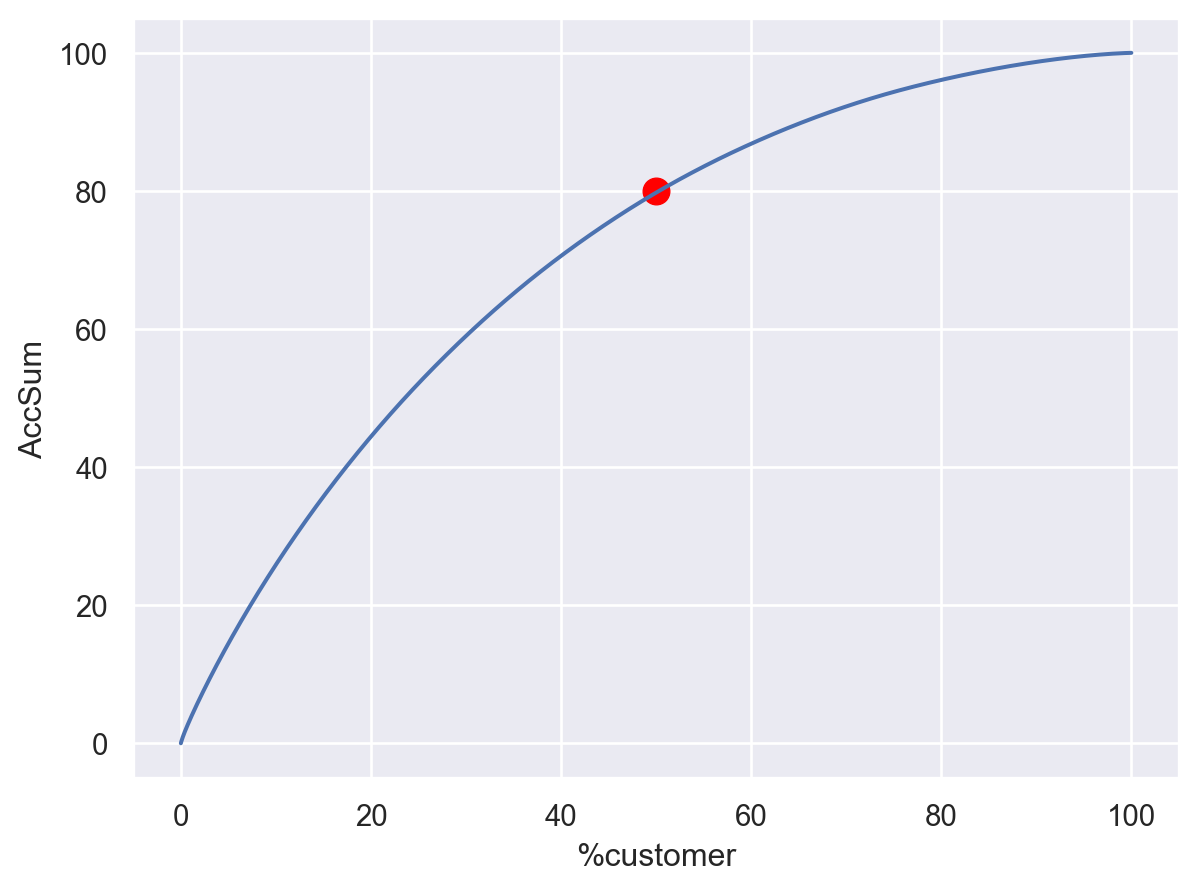

In [142]:
(
    so.Plot(data=df_pareto, x='%customer', y='AccSum')
    .add(so.Line())
    .add(so.Dot(color='red', pointsize=10), data={'x1':[50],'y1':[80]}, x='x1', y='y1')
)

En el grafico podemos ver que aproximadamente el 50% de los clientes concentran el 80% del revenue total como habiamos calculado antes con SQL y la distribucion del revenue es mas pareja que una distribucion clasica de Pareto 80/20. El peso de la salud del negocio recae sobre la mitad de los clientes. Por lo tanto, la otra mitad no resulta determinante. Las posibles decisiones sobre fidelizacion deben apuntar a la primer mitad.

4.¿Cuál es el nivel de retención de nuestros clientes?

Empezamos con la consulta en DBeaver con SQL. Luego continuamos con la misma estructura en Pandas.

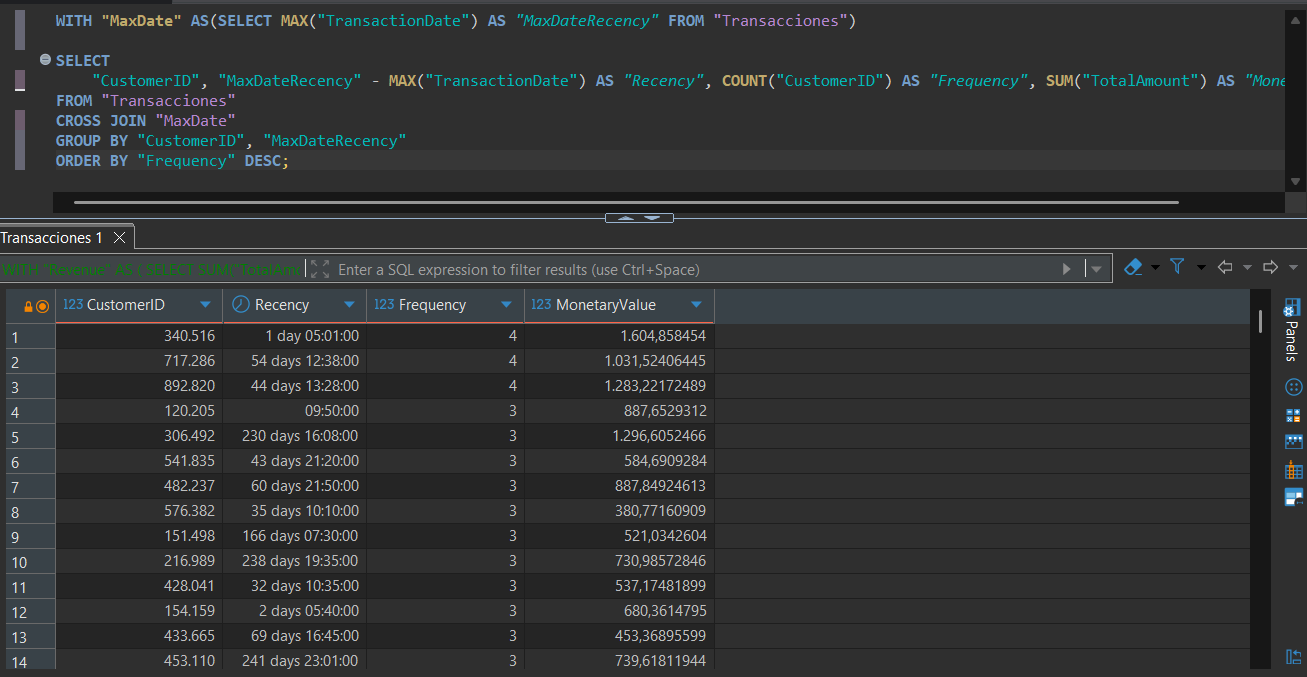

In [245]:
fecha_corte = df_transactions['TransactionDate'].max()
df_rfm = df_transactions.groupby('CustomerID').agg(MaxDate=('TransactionDate','max'), Frequency=('CustomerID','count'), MonetaryValue=('TotalAmount','sum')).reset_index()
df_rfm['Recency'] = (fecha_corte - df_rfm['MaxDate']).dt.days
display(df_rfm)

,CustomerID,MaxDate,Frequency,MonetaryValue,Recency
0,14,2023-08-06 06:45:00,1,256.232791,266
1,42,2023-05-19 21:52:00,1,502.656523,345
2,49,2023-06-05 13:10:00,1,21.399047,328
3,59,2024-04-01 01:06:00,2,249.492696,27
4,65,2023-06-18 10:29:00,1,548.006625,315
...,...,...,...,...,...
95210,999910,2023-10-13 08:22:00,1,12.441084,198
95211,999931,2023-09-04 15:47:00,1,105.039745,237
95212,999977,2023-07-03 10:19:00,1,71.135444,300
95213,999990,2023-08-26 10:48:00,1,195.449291,246


Vamos a separar en cuantiles la recencia para segmentar a los clientes entre activos, en riesgo y perdidos. Los mismos datos nos van a decir donde se encuentran los cortes.

In [203]:
df_rfm['Recency'].max()

np.int64(364)

In [204]:
p33 = df_rfm['Recency'].quantile(0.33)
p66 = df_rfm['Recency'].quantile(0.66)
print(p33,p66)

115.0 236.0


In [205]:
df_rfm['Segment'] = df_rfm['Recency'].apply(lambda x:"Activo" if x<=p33 else("En Riesgo" if x<=p66 else "Perdido"))
display(df_rfm)

,CustomerID,MaxDate,Frequency,MonetaryValue,Recency,Segment
0,14,2023-08-06 06:45:00,1,256.232791,266,Perdido
1,42,2023-05-19 21:52:00,1,502.656523,345,Perdido
2,49,2023-06-05 13:10:00,1,21.399047,328,Perdido
3,59,2024-04-01 01:06:00,2,249.492696,27,Activo
4,65,2023-06-18 10:29:00,1,548.006625,315,Perdido
...,...,...,...,...,...,...
95210,999910,2023-10-13 08:22:00,1,12.441084,198,En Riesgo
95211,999931,2023-09-04 15:47:00,1,105.039745,237,Perdido
95212,999977,2023-07-03 10:19:00,1,71.135444,300,Perdido
95213,999990,2023-08-26 10:48:00,1,195.449291,246,Perdido


In [206]:
df_rfm['Segment'].value_counts()

Segment
Perdido      32334
En Riesgo    31457
Activo       31424
Name: count, dtype: int64

Esto me dice que la distribucion es pareja, por lo tanto la suma entre "En Riesgo" y "Activos" es el doble de "Perdidos". Analicemos la frecuencia de los clientes para entender esta segmentacion.

In [213]:
print(f"El maximo es: {df_rfm['Frequency'].max()}")
#-------------------------------------------
print(f"La media es: {df_rfm['Frequency'].mean()}")
#-------------------------------------------
print(f"La mediana es:{df_rfm['Frequency'].median()}")

El maximo es: 4
La media es: 1.0502546867615397
La mediana es:1.0


Esto nos indica que la gran mayoria de los clientes compraron una sola vez. Usemos esto para crear etiquetas que guien el accionar sobre estos clientes.

In [219]:
df_rfm['Frequency'].value_counts()

Frequency
1    90594
2     4460
3      158
4        3
Name: count, dtype: int64

Para ser un poco mas precisos, mas del 95% de los clientes compraron una sola vez.

In [239]:
def etiquetar(f: int, s: str):
    if f>1 and s=='Activo':
        return 'VIP'
    elif f==1 and s=='Activo':
        return 'Potencial Activo'
    elif f>1 and s=='Perdido':
        return 'Fuga Critica'
    elif f==1 and s=='Perdido':
        return 'Paseante'
    elif f>1 and s=='En Riesgo':
        return 'Potencial Activo Perdido'
    elif f==1 and s=='En Riesgo':
        return 'Potencial Perdido'
    
df_rfm['Label'] = df_rfm.apply(lambda row: etiquetar(row['Frequency'],row['Segment']), axis=1)
display(df_rfm)

,CustomerID,MaxDate,Frequency,MonetaryValue,Recency,Segment,Label
0,14,2023-08-06 06:45:00,1,256.232791,266,Perdido,Paseante
1,42,2023-05-19 21:52:00,1,502.656523,345,Perdido,Paseante
2,49,2023-06-05 13:10:00,1,21.399047,328,Perdido,Paseante
3,59,2024-04-01 01:06:00,2,249.492696,27,Activo,VIP
4,65,2023-06-18 10:29:00,1,548.006625,315,Perdido,Paseante
...,...,...,...,...,...,...,...
95210,999910,2023-10-13 08:22:00,1,12.441084,198,En Riesgo,Potencial Perdido
95211,999931,2023-09-04 15:47:00,1,105.039745,237,Perdido,Paseante
95212,999977,2023-07-03 10:19:00,1,71.135444,300,Perdido,Paseante
95213,999990,2023-08-26 10:48:00,1,195.449291,246,Perdido,Paseante


In [240]:
df_labels = df_rfm['Label'].value_counts().reset_index()
df_labels.columns = ['Labels','Quantity']
total_quantity = df_labels['Quantity'].sum()
df_labels['Percentage'] = df_labels['Quantity'].apply(lambda x: round((x/total_quantity)*100,2))
display(df_labels)

,Labels,Quantity,Percentage
0,Paseante,31792,33.39
1,Potencial Perdido,29910,31.41
2,Potencial Activo,28892,30.34
3,VIP,2532,2.66
4,Potencial Activo Perdido,1547,1.62
5,Fuga Critica,542,0.57


Sumando las categorias que tienen una frecuencia igual a 1 corroboramos el analisis anterior sobre la frecuencia de compra del 95% de los clientes. Ademas, vemos que el 2.66% de los clientes pueden ser los que empujan el negocio. Seria interesante en otro analisis ver cual es el ticket representativo de ese segmento y que categorias compran. Creo que hacer foco sobre los "Potencial Activo Perdido" no seria muy util ya que no representan gran parte del total mas si centrar acciones sobre "Potencial Perdido" para evitar fugas importantes.

5.¿En qué horario existe la mayor cantidad de transacciones?

En la primer etapa, durante el proceso de ETL, transformamos la columna de 'TransactionDate' para separar las horas, nos queda una consulta mas sencilla en SQL.

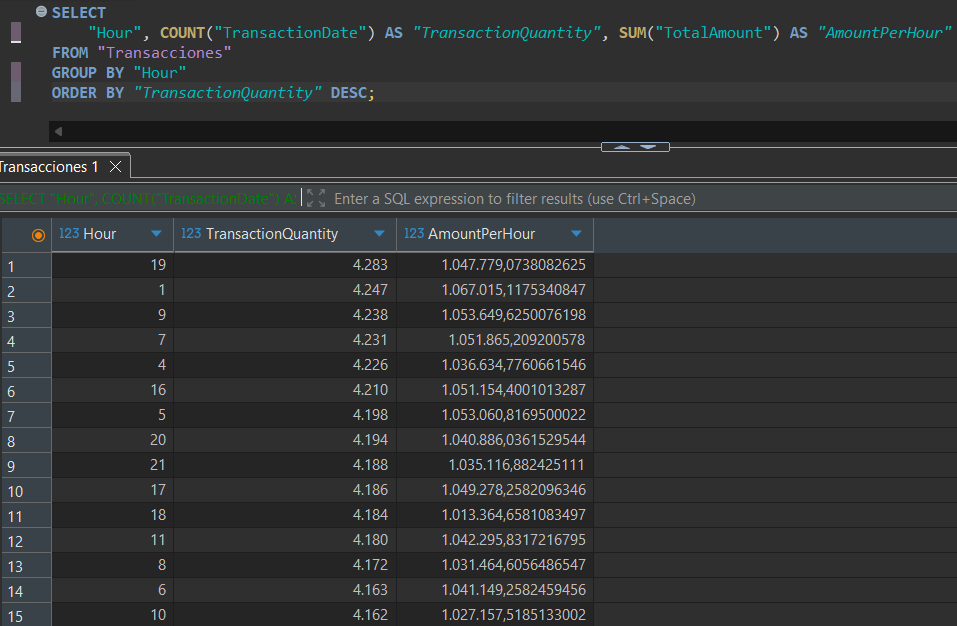

Replicamos lo mismo en Pandas.

In [247]:
df_hora = df_transactions.groupby('Hour').agg(TransactionQuantity=('TransactionDate','count'), AmountPerHour=('TotalAmount','sum'))
df_hora.sort_values(by='TransactionQuantity', ascending=False)

,TransactionQuantity,AmountPerHour
Hour,,
19,4283,1.047779e+06
1,4247,1.067015e+06
9,4238,1.053650e+06
7,4231,1.051865e+06
4,4226,1.036635e+06
16,4210,1.051154e+06
5,4198,1.053061e+06
20,4194,1.040886e+06
21,4188,1.035117e+06


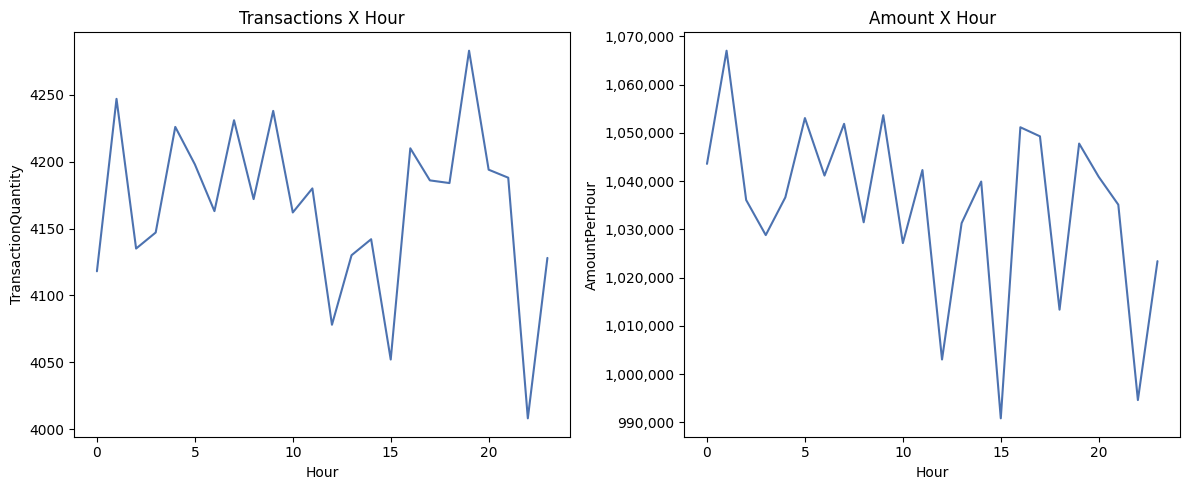

In [272]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
(
    so.Plot(data=df_hora, x='Hour', y='TransactionQuantity')
    .add(so.Line())
    .label(title='Transactions X Hour')
    .on(ax[0])
    .plot()
)
(
    so.Plot(data=df_hora, x='Hour', y='AmountPerHour')
    .add(so.Line())
    .label(title='Amount X Hour')
    .on(ax[1])
    .plot()
)
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()

La mayor cantidad de transacciones se realizan a las 19 horas. Notar que a esta hora el monto que se acumula no es el mayor; este se acumula cerca de la 1 de la madrugada.

In [292]:
df_categorias = df_transactions[['ProductCategory','Hour']]
df_hora_19 = df_categorias[df_categorias['Hour']==19]
df_hora_19['ProductCategory'].value_counts()

ProductCategory
Home Decor     1104
Books          1098
Clothing       1052
Electronics    1029
Name: count, dtype: int64

In [293]:
df_hora_1 = df_categorias[df_categorias['Hour']==1]
df_hora_1['ProductCategory'].value_counts()

ProductCategory
Clothing       1087
Electronics    1082
Home Decor     1050
Books          1028
Name: count, dtype: int64

In [307]:
matriz_categorias = pd.crosstab(df_transactions['Hour'], df_transactions['ProductCategory'])
display(matriz_categorias.loc[[1,19]])

ProductCategory,Books,Clothing,Electronics,Home Decor
Hour,,,,
1,1028,1087,1082,1050
19,1098,1052,1029,1104


Entrando un poco mas en el analisis de las transacciones por hora vemos que a las 19 horas la categoria que mas vende es Home Decor mientras que a la 1 la que mas vende es Clothing. Podriamos ahondar un poco mas si tuvieramos los margenes de los productos por categoria para saber cual resulta mas rentable aunque se escapa de la idea principal ademas de que no contamos con esos datos. Teniendo en cuenta lo visto podria sugerir que las categorias de Home Decor y Clothing empujen horas de venta que se encuentran bajas con ofertas o promociones pero esto "correria" las ventas que se dan en horarios picos, no generan mas revenue lo que motiva pensar que se ofrezcan promociones que incentiven una compra mayor en estos horarios picos o, en caso de ofrecer envios, se bonifique con un monto base en dichas categorias.